In [1]:
# ! source get_paths.sh web sf_curr

In [1]:
import os
os.environ['DATASET_PATH'] = '/shared/john/model_training/'
os.environ['CUDA_VISIBLE_DEVICES'] = '0'


In [2]:
import os 
import argparse
import torch
import os
from omegaconf import OmegaConf
from tqdm import tqdm
from torchvision import transforms
from torchvision.io import write_video
from einops import rearrange
import torch.distributed as dist
from torch.utils.data import DataLoader, SequentialSampler
from torch.utils.data.distributed import DistributedSampler

from pipeline import (
    CausalDiffusionInferencePipeline,
    CausalInferencePipeline,
    ProgressiveCausalInferencePipeline
)
from utils.dataset import TextDataset, TextImagePairDataset
from utils.misc import set_seed

from demo_utils.memory import gpu, get_cuda_free_memory_gb, DynamicSwapInstaller

/shared/miniconda3/envs/self_forcing/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
parser = argparse.ArgumentParser()
parser.add_argument("--config_path", type=str, help="Path to the config file")
parser.add_argument("--checkpoint_path", type=str, help="Path to the checkpoint folder")
parser.add_argument("--data_path", type=str, help="Path to the dataset")
parser.add_argument("--extended_prompt_path", type=str, help="Path to the extended prompt")
parser.add_argument("--output_folder", type=str, help="Output folder")
parser.add_argument("--num_output_frames", type=int, default=21,
                    help="Number of overlap frames between sliding windows")
parser.add_argument("--i2v", action="store_true", help="Whether to perform I2V (or T2V by default)")
parser.add_argument("--use_ema", action="store_true", help="Whether to use EMA parameters")
parser.add_argument("--seed", type=int, default=0, help="Random seed")
parser.add_argument("--num_samples", type=int, default=1, help="Number of samples to generate per prompt")
parser.add_argument("--save_with_index", action="store_true",
                    help="Whether to save the video using the index or prompt as the filename")
parser.add_argument("--first_window_size", type=int, default=7,
                    help="how many latent frames are in the first window?")

args = parser.parse_args([])

# for own trained model using the progressive window strategy
# args.config_path = "/shared/john/model_training/john_env/self_forcing_clone/self_forcing/model_training/260203_view_dmd_windows/view_dmd_windows.yaml"
# args.checkpoint_path = "/shared/john/model_training/john_env/self_forcing_clone/self_forcing/model_training/260203_view_dmd_windows/logs/checkpoint_model_000750/model.pt"
# args.premade_model = False


# self-forcing
args.config_path = "/shared/john/model_training/john_env/self_forcing_clone/self_forcing/premade_models/self_forcing_dmd.yaml"
args.checkpoint_path = "/shared/john/model_training/john_env/self_forcing_clone/self_forcing/premade_models/self_forcing_dmd.pt"
args.premade_model = True
args.use_ema = True
args.first_window_size = 1


# causal-forcing
# args.config_path = "/home/john_zhou/research/arvd_repos/sf_curr/configs/260310_smaller_window/260310_smaller_window.yaml" # limit chunk size, with sink
args.config_path = "/shared/john/model_training/john_env/self_forcing_clone/self_forcing/premade_models/self_forcing_dmd.yaml" # limit to sliding window of 21

# args.checkpoint_path = "/shared/john/model_training/john_env/self_forcing_clone/self_forcing/premade_models/causal_forcing/chunkwise/causal_forcing.pt"
# args.checkpoint_path = "/shared/john/model_training/john_env/self_forcing_clone/self_forcing/premade_models/self_forcing_dmd.pt"

# args.premade_model = True
args.use_ema = False if 'causal_forcing' in args.checkpoint_path else True

args.first_window_size = 7 # test out generation with these models under the full bidirecitonal setting




In [5]:
# misc setup
# Initialize distributed inference
if "LOCAL_RANK" in os.environ:
    dist.init_process_group(backend='nccl')
    local_rank = int(os.environ["LOCAL_RANK"])
    torch.cuda.set_device(local_rank)
    device = torch.device(f"cuda:{local_rank}")
    world_size = dist.get_world_size()
    set_seed(args.seed + local_rank)
else:
    device = torch.device("cuda")
    local_rank = 0
    world_size = 1
    set_seed(args.seed)
    

torch.set_grad_enabled(False)

config = OmegaConf.load(args.config_path)
default_config = OmegaConf.load("configs/default_config.yaml")
config = OmegaConf.merge(default_config, config)

In [6]:
if 'self_forcing_dmd' in args.config_path:
    config.model_kwargs['local_attn_size'] = 21 

In [7]:
# Model loading

pipeline = ProgressiveCausalInferencePipeline(config,device=device, initial_first_window_size= args.first_window_size)
# pipeline = CausalInferencePipeline(config, device=device)

print("type(pipeline)",type(pipeline))

if args.checkpoint_path:
    state_dict = torch.load(args.checkpoint_path, map_location="cpu")
    # Trained model has misnamed parameters
    # pipeline.generator.load_state_dict(state_dict['generator' if not args.use_ema else 'generator_ema'])
    if not args.premade_model:
        if args.use_ema:
            temporary_state_dict = {k.replace("._fsdp_wrapped_module",""):v for k,v in state_dict['generator_ema'].items()}
        else:
            temporary_state_dict = {k.replace("._fsdp_wrapped_module",""):v for k,v in state_dict['generator'].items()}
    else:
        temporary_state_dict = state_dict['generator' if not args.use_ema else 'generator_ema']
    pipeline.generator.load_state_dict(temporary_state_dict)

# pipeline = pipeline.to(dtype=torch.bfloat16)
pipeline.text_encoder.to(device=gpu)
pipeline.generator.to(device=gpu)
pipeline.vae.to(device=gpu)

pipeline = pipeline.to(device="cuda", dtype=torch.bfloat16)


using 1.3b model


KV inference with 3 frames per block
type(pipeline) <class 'pipeline.progressive_causal_inference.ProgressiveCausalInferencePipeline'>


In [8]:
pipeline.generator.model.sink_size, pipeline.generator.model.local_attn_size

/tmp/ipykernel_3434144/3980903773.py:1: FutureWarning: Accessing config attribute `sink_size` directly via 'CausalWanModel' object attribute is deprecated. Please access 'sink_size' over 'CausalWanModel's config object instead, e.g. 'unet.config.sink_size'.
  pipeline.generator.model.sink_size, pipeline.generator.model.local_attn_size


(0, 21)

In [9]:
args.num_output_frames = 21 # originally 21~5s, so 21*6 ~ 15s
sampled_noise = torch.randn(
            [args.num_samples, args.num_output_frames, 16, 60, 104], device=device, dtype=torch.bfloat16
        )

text_prompt = "A stylish woman strolls down a bustling Tokyo street, the warm glow of neon lights and animated city signs casting vibrant reflections. She wears a sleek black leather jacket paired with a flowing red dress and black boots, her black purse slung over her shoulder. Sunglasses perched on her nose and a bold red lipstick add to her confident, casual demeanor. The street is damp and reflective, creating a mirror-like effect that enhances the colorful lights and shadows. Pedestrians move about, adding to the lively atmosphere. The scene is captured in a dynamic medium shot with the woman walking slightly to one side, highlighting her graceful strides."
# text_prompt = "Two people dancing in the rain"
# text_prompt = "A close-up 3D animated scene of a short, fluffy monster kneeling beside a melting red candle. The monster has large, wide eyes and an open mouth, gazing at the flame with a look of wonder and curiosity. Its soft, fluffy fur contrasts with the warm, dramatic lighting that highlights every detail of its gentle, innocent expression. The pose conveys a sense of playfulness and exploration, as if the creature is discovering the world for the first time. The background features a cozy, warmly lit room with subtle hints of a fireplace and soft furnishings, enhancing the overall atmosphere. The use of warm colors and dramatic lighting creates a captivating and inviting scene."
# text_prompt = "A dynamic rally car speeding through a tight turn on a winding track, tires screeching as it navigates the curves with precision."
negative_prompt = '色调艳丽，过曝，静态，细节模糊不清，字幕，风格，作品，画作，画面，静止，整体发灰，最差质量，低质量，JPEG压缩残留，丑陋的，残缺的，多余的手指，画得不好的手部，画得不好的脸部，畸形的，毁容的，形态畸形的肢体，手指融合，静止不动的画面，杂乱的背景，三条腿，背景人很多，倒着走'

prompts = [text_prompt] * args.num_samples
negative_prompts = [negative_prompt] * args.num_samples


In [10]:
sampled_noise.shape

torch.Size([1, 21, 16, 60, 104])

In [11]:
# pipeline.first_window_size = 7

In [12]:

video, latents = pipeline.inference_deterministic(
            noise=sampled_noise,
            text_prompts=prompts,
            return_latents=True
        )

progressive_enabled: True
all_num_frames: [21]
current_timestep: 1000.0


RuntimeError: Expected a 'cuda' device type for generator but found 'cpu'

In [ ]:
"""

storage_of_noise[curr_block_idx] = sampled_noise
storage_of_noise[curr_block_idx] = sampled_noise

"""

In [ ]:

video2, latents2 = pipeline.inference_deterministic(
            noise=sampled_noise,
            text_prompts=prompts,
            return_latents=True
        )

progressive_enabled: True
all_num_frames: [21]
current_timestep: 1000.0
start: 1
end: 1
current_timestep: 937.5
start: 2
end: 2
current_timestep: 833.3333129882812
start: 3
end: 3
current_timestep: 625.0
current_start_frame: 0
current_num_frames: 21


In [ ]:
def sampled_noise_determinstic():
    # deterministicly change the noise for each step
    # sampled_start_rolling = current_start_frame+1 % original_sampled_noise.shape[1]
    sampled_start_rolling = current_start_frame+1 % original_sampled_noise.shape[0]
    sampled_end_rolling = (current_start_frame + current_num_frames - num_input_frames +1)% original_sampled_noise.shape[0]

    # sampled_end_rolling = (current_start_frame + current_num_frames - num_input_frames +1)% original_sampled_noise.shape[1]
    print("start:", sampled_start_rolling)
    print("end:", sampled_end_rolling)
    
    if sampled_start_rolling < sampled_end_rolling:
        # sampled_noise_for_current_step = original_sampled_noise[:, sampled_start_rolling:sampled_end_rolling, ...]
        sampled_noise_for_current_step = original_sampled_noise[:, sampled_start_rolling:sampled_end_rolling]

    else:
        # sampled_noise_for_current_step = torch.cat([
        #     original_sampled_noise[:, sampled_start_rolling:, ...],
        #     original_sampled_noise[:, :sampled_end_rolling, ...]
        # ], dim=1)
        sampled_noise_for_current_step = torch.cat([
            original_sampled_noise[:, sampled_start_rolling:],
            original_sampled_noise[:, :sampled_end_rolling]
        ], dim=1)
    return sampled_noise_for_current_step


original_sampled_noise = torch.arange(21)
num_input_frames = 0
current_num_frames = 3
current_start_frame = 0 


In [ ]:
# g = torch.Generator()
# g.manual_seed( torch.norm(sampled_noise) )
# torch.randn(3, generator=g)


# torch.sum(torch.randn([1,21,16,60,104])).


# int(torch.sum(torch.randn([1,21,16,60,104])).item())

2185

In [ ]:
def type_correct_video(video):
    video = (video * 0.5 + 0.5).clamp(0, 1)
    video = 255.0 * video
    return video

def convert_latent_to_video(latent):
    latent = latent.to(dtype=torch.bfloat16)
    video = pipeline.vae.decode_to_pixel(latent)
    return type_correct_video(video)

vid_from_latent = convert_latent_to_video(latents)
vid_from_latent2 = convert_latent_to_video(latents2)

# video = type_correct_video(video)



NameError: name 'latents' is not defined

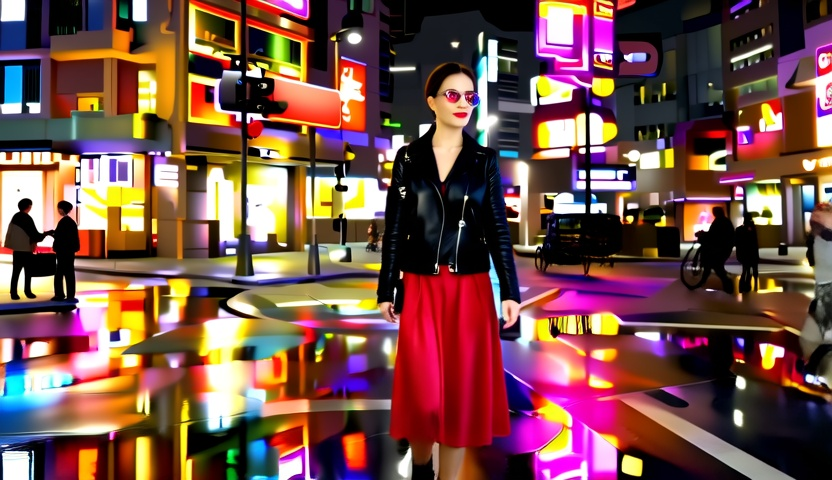

In [ ]:
import os 
import cv2
from IPython.display import Image, display, clear_output
import time
import torch
from einops import rearrange


def view_video_numpy(video, prompt):
    """
    video should be in the shape of (B, T, C, H, W)"""
    fps = 1/16 #16fps

    # video = video.reshape(video.shape[0], video.shape[1], video.shape[3], video.shape[4], video.shape[2]) # [b,T,H,W,C]
    video = rearrange(video, 'b t c h w -> b t h w c') # [b,T,H,W,C]

    video_frame_list = video[0].cpu().numpy()
    # print(video_frame_list.shape)
    
    print(video_frame_list.shape)
    for video_frame in video_frame_list:
        # print(video_frame.shape)
        clear_output(wait=True)
        rgb_frame = cv2.cvtColor(video_frame,cv2.COLOR_BGR2RGB)
        # rgb_frame = video_frame
        _, encoded_image = cv2.imencode('.jpeg',rgb_frame)
        display(Image(data=encoded_image.tobytes()))
        # print(prompt)
        time.sleep(fps)

view_video_numpy(vid_from_latent, "text") 
# view_video_numpy(vid_from_latent2, "text") 

# view_video_numpy(video, "text")

# write_video("sf_long_video_sink3_local12.mp4", video, fps=16)
# write_video("sf_long_video_sink0_local21.mp4", video, fps=16)

# write_video("cf_long_video_sink0_local21.mp4", video, fps=16)
# write_video("cf_long_video_sink3_local12.mp4", video, fps=16)


In [ ]:
torch.nn.MSELoss()(latents, latents2)

tensor(0., device='cuda:0', dtype=torch.bfloat16)

In [ ]:
# # break

# video_latent_save = rearrange(vid_from_latent, 'b t c h w -> b t h w c') # [b,T,H,W,C]
# video_latent_save = video_latent_save.squeeze(0).cpu().numpy()
# # write_video("non-causal_racecar_video_chunk3.mp4", video_latent_save, fps=16)
# # write_video("sf_racecar_video_chunk21.mp4", video_latent_save, fps=16)
# # write_video("sf_tokyo_video_chunk3.mp4", video_latent_save, fps=16)
# write_video("sf_tokyo_video_chunk21.mp4", video_latent_save, fps=16)



In [ ]:
pipeline.generator.model.sink_size

/tmp/ipykernel_3411999/1822029575.py:1: FutureWarning: Accessing config attribute `sink_size` directly via 'CausalWanModel' object attribute is deprecated. Please access 'sink_size' over 'CausalWanModel's config object instead, e.g. 'unet.config.sink_size'.
  pipeline.generator.model.sink_size


0